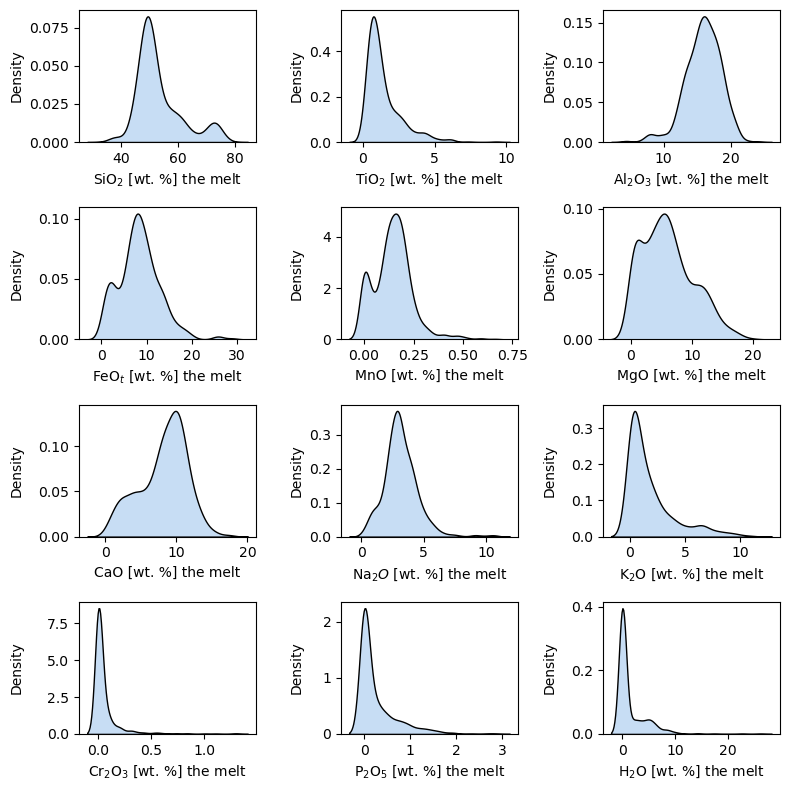

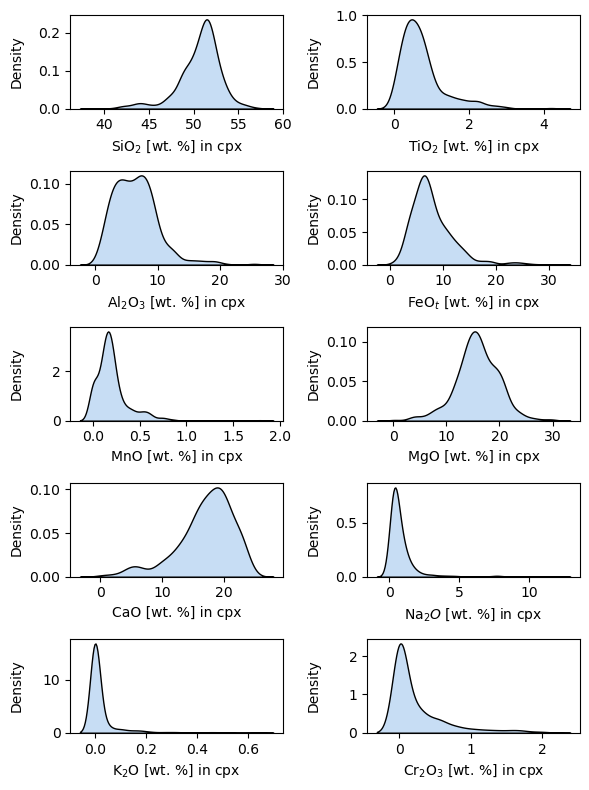

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn# adalah library Python yang digunakan untuk
#Machine Learning
#Data Mining
#Analisis
data.preprocessing import StandardScaler #adalah alat dari library scikit-learn yang digunakan untuk normalisasi data.
from sklearn.ensemble import ExtraTreesRegressor #Model regresi berbasis ensemble (gabungan banyak model) dari scikit-learn.
from sklearn.metrics import mean_squared_error #adalah fungsi dari library scikit-learn yang digunakan untuk menghitung error rata-rata kuadrat.
from sklearn.metrics import r2_score #adalah fungsi dari library scikit-learn yang digunakan untuk menghitung koefisien determinasi.

# Import The Training Data Set
my_training_dataset = pd.read_excel('GlobalDataset_Final_rev9_TrainValidation.xlsx', usecols = "A:M,O:X,Z:AA", skiprows=1, engine='openpyxl') #mengimpor dataset pelatihan dari file Excel, dengan memilih kolom tertentu dan melewati baris pertama (header).
my_training_dataset.columns = [c.replace('.1', 'cpx') for c in my_training_dataset.columns] #mengganti nama kolom yang mengandung '.1' dengan 'cpx' untuk membedakan antara data komposisi melt dan cpx.
my_training_dataset = my_training_dataset.fillna(0) #mengisi nilai yang hilang (NaN) dalam dataset dengan 0, untuk memastikan bahwa tidak ada nilai kosong yang dapat menyebabkan masalah dalam analisis atau pemodelan selanjutnya.

train_labels = np.array([my_training_dataset.Sample_ID]).T #mengambil kolom 'Sample_ID' dari dataset pelatihan dan mengubahnya menjadi array NumPy
X0_train = my_training_dataset.iloc[:, 1:23] #memilih kolom dari indeks 1 hingga 22 (total 22 kolom) dari dataset pelatihan untuk digunakan sebagai fitur (X) dalam model pembelajaran mesin.
Y_train = np.array([my_training_dataset.T_K]).T #memilih kolom 'T_K' dari dataset pelatihan dan mengubahnya menjadi array NumPy untuk digunakan sebagai target (Y) dalam model pembelajaran mesin.

fig = plt.figure(figsize=(8,8)) #membuat sebuah figure dengan ukuran 8x8 inci untuk menampilkan grafik-grafik yang akan dibuat selanjutnya.
x_labels_melt = [r'SiO$_2$', r'TiO$_2$', r'Al$_2$O$_3$', r'FeO$_t$', r'MnO', r'MgO', r'CaO', r'Na$_2O$', r'K$_2$O', r'Cr$_2$O$_3$', r'P$_2$O$_5$', r'H$_2$O']
for i in range(0,12):#melakukan iterasi untuk setiap kolom fitur melt (total 12 kolom) dan membuat subplot untuk masing-masing fitur tersebut.
    ax1 = fig.add_subplot(4, 3, i+1) #menambahkan subplot ke dalam figure yang telah dibuat, dengan jumlah baris 4 dan jumlah kolom 3, serta menentukan posisi subplot berdasarkan indeks iterasi (i+1).
    sns.kdeplot(X0_train.iloc[:, i],fill=True, color='k', facecolor='#c7ddf4', ax = ax1) # menggunakan seaborn untuk membuat plot kepadatan kernel (KDE) dari data fitur melt pada kolom ke-i, dengan mengisi area di bawah kurva, menggunakan warna hitam untuk garis dan warna biru muda untuk
    ax1.set_xlabel(x_labels_melt[i] + ' [wt. %] the melt') #menetapkan label sumbu x untuk subplot saat ini, dengan menggunakan nama fitur melt yang sesuai dari daftar x
fig.align_ylabels()
fig.tight_layout() 

fig1 = plt.figure(figsize=(6,8))
x_labels_cpx = [r'SiO$_2$', r'TiO$_2$', r'Al$_2$O$_3$', r'FeO$_t$', r'MnO', r'MgO', r'CaO', r'Na$_2O$', r'K$_2$O', r'Cr$_2$O$_3$']
for i in range(0,10):
    ax2 = fig1.add_subplot(5, 2, i+1)
    sns.kdeplot(X0_train.iloc[:, i+12],fill=True, color='k', facecolor='#c7ddf4', ax = ax2)
    ax2.set_xlabel(x_labels_cpx[i] + ' [wt. %] in cpx')
fig1.align_ylabels()
fig1.tight_layout()









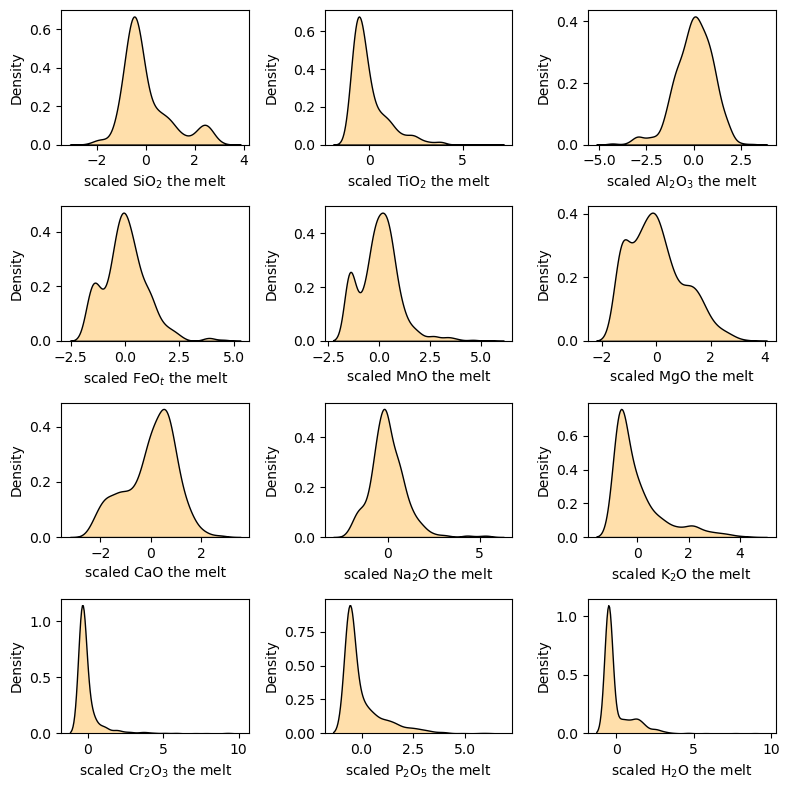

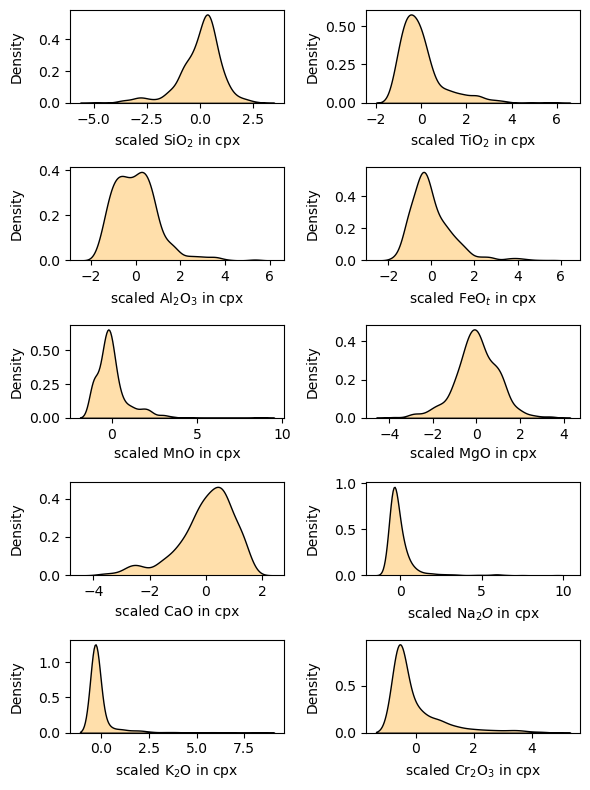

In [ ]:
scaler = StandardScaler().fit(X0_train) #membuat objek StandardScaler dan menyesuaikannya dengan data fitur melt (X0_train) untuk menghitung rata-rata dan standar deviasi yang akan digunakan untuk normalisasi data.
X_train = scaler.transform(X0_train) #menggunakan objek StandardScaler yang telah dibuat untuk mentransformasikan data fitur melt (X0_train) menjadi data yang telah dinormalisasi (X_train), dengan mengurangi rata-rata dan membagi dengan standar deviasi untuk setiap fitur, sehingga menghasilkan data yang memiliki distribusi dengan rata-rata 0 dan standar deviasi 1.

fig2 = plt.figure(figsize=(8,8)) # membuat objek figure dengan ukuran 8x8 inci
for i in range(0,12): 
    ax3 = fig2.add_subplot(4, 3, i+1) 
    sns.kdeplot(X_train[:, i],fill=True, color='k', facecolor='#ffdfab', ax = ax3)
    ax3.set_xlabel('scaled ' + x_labels_melt[i] + ' the melt')
fig2.align_ylabels()
fig2.tight_layout()

fig3 = plt.figure(figsize=(6,8))
for i in range(0,10):
    ax4 = fig3.add_subplot(5, 2, i+1)
    sns.kdeplot(X_train[:, i+12],fill=True, color='k', facecolor='#ffdfab', ax = ax4)
    ax4.set_xlabel('scaled ' + x_labels_cpx[i] + ' in cpx')
fig3.align_ylabels()
fig3.tight_layout()


Text(0, 0.5, 'Predicted Temperature values [K]')

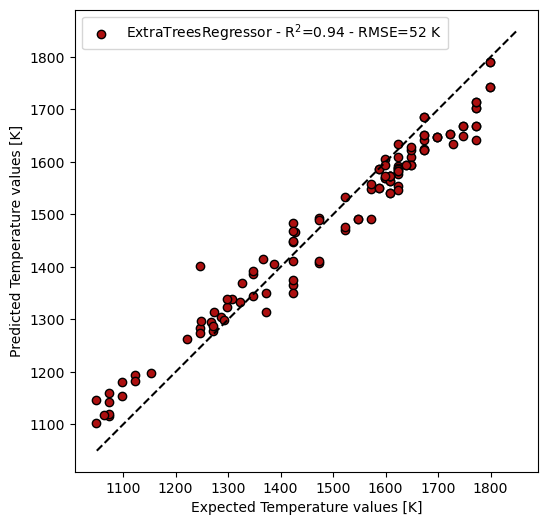

In [ ]:

regr = ExtraTreesRegressor(n_estimators=550, criterion='squared_error', max_features=22, random_state=280) # mendefinisikan model regresi yang akan digunakan, yaitu ExtraTreesRegressor, dengan parameter n_estimators=550 (jumlah pohon dalam ensemble), criterion='squared_error' (metode untuk mengukur kualitas split), max_features=22 (jumlah fitur yang dipertimbangkan untuk setiap split), dan random_state=280 (untuk memastikan hasil yang konsisten).

regr.fit(X_train, Y_train.ravel()) #melatih model regresi yang telah didefinisikan (regr) menggunakan data fitur yang telah dinormalisasi (X_train) dan target (Y_train), dengan meratakan array target untuk memastikan bahwa formatnya sesuai dengan yang diharapkan oleh model.

# Import the test data set 
my_test_dataset = pd.read_excel('GlobalDataset_Final_rev9_Test.xlsx', usecols = "A:M,O:X,Z:AA", skiprows=1, engine='openpyxl')# mengimpor dataset pengujian dari file Excel, dengan memilih kolom tertentu dan melewati baris pertama (header).
my_test_dataset.columns = [c.replace('.1', 'cpx') for c in my_test_dataset.columns] # mengganti nama kolom yang mengandung '.1' dengan 'cpx' untuk membedakan antara data komposisi melt dan cpx dalam dataset pengujian.
my_test_dataset = my_test_dataset.fillna(0) #mengisi nilai yang hilang (NaN) dalam dataset pengujian dengan 0, untuk memastikan bahwa tidak ada nilai kosong yang dapat menyebabkan masalah dalam analisis atau pemodelan selanjutnya.

X0_test = my_test_dataset.iloc[:, 1:23] #memilih kolom dari indeks 1 hingga 22 (total 22 kolom) dari dataset pengujian untuk digunakan sebagai fitur (X) dalam model pembelajaran mesin.
Y_test= np.array([my_test_dataset.T_K]).T #memilih kolom 'T_K' dari dataset pengujian dan mengubahnya menjadi array NumPy untuk digunakan sebagai target (Y) dalam evaluasi model pembelajaran mesin.
labels_test = np.array([my_test_dataset.Sample_ID]).T #mengambil kolom 'Sample_ID' dari dataset pengujian dan mengubahnya menjadi array NumPy untuk digunakan sebagai label dalam evaluasi model pembelajaran mesin.

# Scale the test dataset
X_test_scaled = scaler.transform(X0_test) #menggunakan objek StandardScaler yang telah dibuat sebelumnya untuk mentransformasikan data fitur pengujian (X0_test) menjadi data yang telah dinormalisasi (X_test_scaled), dengan menggunakan rata-rata dan standar deviasi yang sama yang dihitung dari data pelatihan, sehingga memastikan bahwa data pengujian memiliki skala yang konsisten dengan data pelatihan.

# Make the prediction on the test data set
predicted = regr.predict(X_test_scaled)  #menggunakan model regresi yang telah dilatih (regr) untuk membuat prediksi pada data fitur pengujian yang telah dinormalisasi (X_test_scaled), menghasilkan array prediksi yang berisi nilai target yang diprediksi oleh model untuk setiap sampel dalam dataset pengujian.

# Evaluate the results using the R2 and RMSE 
r2 = r2_score(Y_test, predicted) #menghitung koefisien determinasi (R^2) antara nilai target aktual (Y_test) dan nilai yang diprediksi oleh model (predicted) menggunakan fungsi r2_score dari scikit-learn, yang memberikan ukuran seberapa baik model menjelaskan variabilitas data.
rmse = np.sqrt(mean_squared_error(predicted, Y_test)) #menghitung Root Mean Squared Error (RMSE) antara nilai yang diprediksi oleh model (predicted) dan nilai target aktual (Y_test) dengan terlebih dahulu menghitung Mean Squared Error (MSE) menggunakan fungsi mean_squared_error dari scikit-learn, kemudian mengambil akar kuadrat dari MSE untuk mendapatkan RMSE, yang memberikan ukuran seberapa jauh prediksi model dari nilai aktual dalam satuan yang sama dengan target.

# Plot data       
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([1050,1850],[1050,1850], c='#000000', linestyle='--')
ax.scatter(Y_test,predicted, color='#ad1010', edgecolor='#000000', label=r"ExtraTreesRegressor - R$^2$=" + "{:.2f}".format(r2) + " - RMSE="+ "{:.0f}".format(rmse) +" K") 
ax.legend()
ax.axis('scaled')
ax.set_xlabel('Expected Temperature values [K]')
ax.set_ylabel('Predicted Temperature values [K]')